<a href="https://colab.research.google.com/github/OmegaS48/MLDL_python/blob/main/Intern_Day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import seaborn as sns

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
normal=pd.read_csv('/content/SDNFlow_Dataset_Normal.csv')

In [ ]:
attack=pd.read_csv('/content/SDNFlow_Dataset_attack.csv')

In [ ]:
d=pd.concat([normal,attack],axis=0)

In [ ]:
d = d.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
d.head()

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,28643,2048,85.114.159.118,192.168.56.203,6,443,39236,15.728,4577,10,...,3.0,199456735,4577,168584,10,10,95,1,0,HTTP
1,269771,2048,10.10.10.99,10.10.10.12,6,64822,1805,0.940,0,0,...,0.0,180,180,3,3,0,168,168,1,probe
2,230209,2048,10.10.10.99,10.10.10.3,6,47729,111,0.986,0,0,...,0.0,0,0,0,0,0,100,100,1,probe
3,414399,2048,10.10.10.4,172.20.0.100,6,23,48750,10.493,4986,63,...,0.0,74800,75140,943,947,63,30,63,1,password-guessing
4,416927,2048,10.10.10.4,172.20.0.100,6,5900,56190,0.752,316,4,...,0.0,59268,59268,752,752,4,181,181,1,password-guessing


In [ ]:
d['Attack'].value_counts()

,count
Attack,
1,441264
0,221564


In [ ]:
d

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack
0,28643,2048,85.114.159.118,192.168.56.203,6,443,39236,15.728,4577,10,...,4,3.0,199456735,4577,168584,10,10,95,1,0
1,269771,2048,10.10.10.99,10.10.10.12,6,64822,1805,0.940,0,0,...,0,0.0,180,180,3,3,0,168,168,1
2,230209,2048,10.10.10.99,10.10.10.3,6,47729,111,0.986,0,0,...,0,0.0,0,0,0,0,0,100,100,1
3,414399,2048,10.10.10.4,172.20.0.100,6,23,48750,10.493,4986,63,...,0,0.0,74800,75140,943,947,63,30,63,1
4,416927,2048,10.10.10.4,172.20.0.100,6,5900,56190,0.752,316,4,...,0,0.0,59268,59268,752,752,4,181,181,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662823,422604,2048,172.20.0.100,10.10.10.4,6,39977,5900,0.116,276,4,...,0,0.0,57582,57582,835,835,835,185,185,1
662824,37615,2048,10.10.10.4,99.230.127.112,6,6000,2500,0.570,0,0,...,0,0.0,0,0,0,0,0,1,94,1
662825,144275,2048,10.10.10.80,172.20.0.100,6,80,41530,10.329,772,5,...,2,1.0,143290,143290,928,928,5,185,185,1
662826,131933,2048,192.168.56.203,200.24.19.252,17,60673,53,0.339,0,0,...,0,0.0,24168,55764,121,299,2,8,42,0


In [ ]:
X=d.drop('Attack',axis=1)
Y=d['Attack']

In [ ]:
X

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP
0,28643,2048,85.114.159.118,192.168.56.203,6,443,39236,15.728,4577,10,...,7.0,4,3.0,199456735,4577,168584,10,10,95,1
1,269771,2048,10.10.10.99,10.10.10.12,6,64822,1805,0.940,0,0,...,0.0,0,0.0,180,180,3,3,0,168,168
2,230209,2048,10.10.10.99,10.10.10.3,6,47729,111,0.986,0,0,...,0.0,0,0.0,0,0,0,0,0,100,100
3,414399,2048,10.10.10.4,172.20.0.100,6,23,48750,10.493,4986,63,...,0.0,0,0.0,74800,75140,943,947,63,30,63
4,416927,2048,10.10.10.4,172.20.0.100,6,5900,56190,0.752,316,4,...,0.0,0,0.0,59268,59268,752,752,4,181,181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662823,422604,2048,172.20.0.100,10.10.10.4,6,39977,5900,0.116,276,4,...,0.0,0,0.0,57582,57582,835,835,835,185,185
662824,37615,2048,10.10.10.4,99.230.127.112,6,6000,2500,0.570,0,0,...,0.0,0,0.0,0,0,0,0,0,1,94
662825,144275,2048,10.10.10.80,172.20.0.100,6,80,41530,10.329,772,5,...,3.0,2,1.0,143290,143290,928,928,5,185,185
662826,131933,2048,192.168.56.203,200.24.19.252,17,60673,53,0.339,0,0,...,0.0,0,0.0,24168,55764,121,299,2,8,42


In [ ]:
Y

,Attack
0,0
1,1
2,1
3,1
4,1
...,...
662823,1
662824,1
662825,1
662826,0


In [ ]:
Y.value_counts()

,count
Attack,
1,441264
0,221564


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
X_train.shape

(530262, 37)

In [ ]:
Y_train.shape

(530262,)

In [ ]:
X_train

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_mean,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP
226578,70621,2048,54.131.128.82,10.10.10.4,17,2375,6667,0.485,0,0,...,0.000000,0,0.000000,0,0,0,0,0,198,1
565093,430380,2048,10.10.10.4,172.20.0.100,6,5900,42349,0.744,382,5,...,0.000000,0,0.000000,79610,79610,1043,1043,5,186,186
565118,50628,2048,192.168.56.203,13.227.19.12,6,38890,80,52.220,3474,14,...,5.857143,2,2.695423,4918,406599,23,2259,46,3,195
408614,368165,2048,172.20.0.100,10.10.10.80,6,35206,80,0.242,654,7,...,0.000000,0,0.000000,128805,128805,1323,1323,1323,187,187
76391,111261,2048,13.35.116.107,192.168.56.203,6,443,35736,0.395,0,0,...,0.000000,0,0.000000,78838334,0,66799,0,0,48,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84434,430665,2048,10.10.10.4,172.20.0.100,6,5900,44455,0.347,382,5,...,0.000000,0,0.000000,78628,78628,1030,1030,5,185,185
437782,219563,2048,10.10.10.16,172.20.0.100,6,1059,33451,0.843,0,0,...,0.000000,0,0.000000,60,60,1,1,1,189,189
620104,219709,2048,172.20.0.100,10.10.10.16,6,64657,5004,0.628,0,0,...,0.000000,0,0.000000,324,324,6,6,0,221,221
203245,338314,2048,10.10.10.19,172.20.0.100,6,1054,52997,0.611,0,0,...,0.000000,0,0.000000,120,120,2,2,2,190,190


In [ ]:
normal=d[d.Attack==0]

In [ ]:
attack=d[d.Attack==1]

In [ ]:
normal.shape

(221564, 38)

In [ ]:
d['Attack'].value_counts()

,count
Attack,
1,441264
0,221564


In [ ]:
d.head()

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_min,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack
0,28643,2048,85.114.159.118,192.168.56.203,6,443,39236,15.728,4577,10,...,4,3.0,199456735,4577,168584,10,10,95,1,0
1,269771,2048,10.10.10.99,10.10.10.12,6,64822,1805,0.940,0,0,...,0,0.0,180,180,3,3,0,168,168,1
2,230209,2048,10.10.10.99,10.10.10.3,6,47729,111,0.986,0,0,...,0,0.0,0,0,0,0,0,100,100,1
3,414399,2048,10.10.10.4,172.20.0.100,6,23,48750,10.493,4986,63,...,0,0.0,74800,75140,943,947,63,30,63,1
4,416927,2048,10.10.10.4,172.20.0.100,6,5900,56190,0.752,316,4,...,0,0.0,59268,59268,752,752,4,181,181,1


In [ ]:
d_emergency=pd.read_csv('/content/SDNFlow_Dataset_attack.csv')

In [ ]:
d_emergency.head()

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,10.10.10.7,71.130.13.134,6,135,2606,9.173,3360,56,...,0.0,3360,15840,56,264,56,1,91,1,ddos
1,2,2048,10.10.10.7,67.130.26.231,6,135,2607,9.173,120,2,...,0.0,120,15840,2,264,2,1,91,1,ddos
2,3,2048,10.10.10.7,140.15.67.247,6,135,2609,9.173,1200,20,...,0.0,1200,15840,20,264,20,1,91,1,ddos
3,4,2048,10.10.10.7,216.140.109.130,6,135,2610,9.168,420,7,...,0.0,420,15840,7,264,7,1,91,1,ddos
4,5,2048,10.10.10.7,100.32.155.56,6,135,2612,9.168,120,2,...,0.0,120,15840,2,264,2,1,91,1,ddos


In [ ]:
d_emergency['Category'].value_counts()

,count
Category,
probe,151456
dos,123807
ddos,74644
password-guessing,67288
sql_injection,17787
u2r,6282


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
labelencoder=LabelEncoder()

In [ ]:
attacktypes=labelencoder.fit_transform(d_emergency.Category)

In [ ]:
d_emergency['Attack']=attacktypes

In [ ]:
d_emergency.head()

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,10.10.10.7,71.130.13.134,6,135,2606,9.173,3360,56,...,0.0,3360,15840,56,264,56,1,91,0,ddos
1,2,2048,10.10.10.7,67.130.26.231,6,135,2607,9.173,120,2,...,0.0,120,15840,2,264,2,1,91,0,ddos
2,3,2048,10.10.10.7,140.15.67.247,6,135,2609,9.173,1200,20,...,0.0,1200,15840,20,264,20,1,91,0,ddos
3,4,2048,10.10.10.7,216.140.109.130,6,135,2610,9.168,420,7,...,0.0,420,15840,7,264,7,1,91,0,ddos
4,5,2048,10.10.10.7,100.32.155.56,6,135,2612,9.168,120,2,...,0.0,120,15840,2,264,2,1,91,0,ddos


In [ ]:
d_emergency['Attack'].value_counts()

,count
Attack,
3,151456
1,123807
0,74644
2,67288
4,17787
5,6282


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote=SMOTE()

In [ ]:
y=d_emergency['Attack']

In [ ]:
y

,Attack
0,0
1,0
2,0
3,0
4,0
...,...
441259,5
441260,5
441261,5
441262,5


In [ ]:
rx=[['dst_port,flow_duration,tot_len_pkts']]

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()

In [ ]:
d_emergency['flow_duration'].value_counts()

,count
flow_duration,
0.500,813
0.600,778
0.800,775
0.700,746
0.400,739
...,...
20.657,1
20.654,1
38.689,1


In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
ros=RandomOverSampler()

In [ ]:
d_emergency.shape

(441264, 39)

In [ ]:
y.shape

(441264,)

In [ ]:
gx,gy=ros.fit_resample(d_emergency,y)

In [ ]:
gx.shape

(908736, 39)

In [ ]:
gy.shape

(908736,)

In [ ]:
import seaborn as sns


<Axes: ylabel='count'>

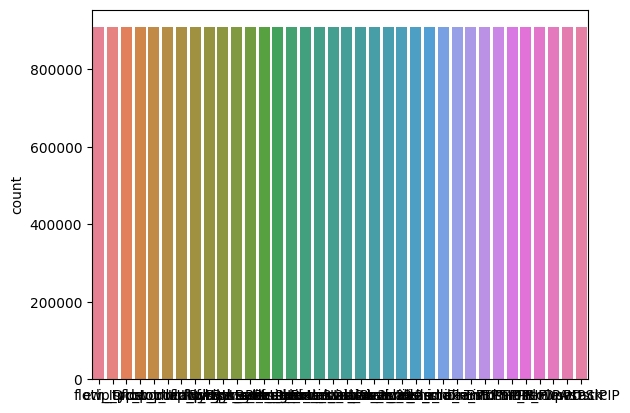

In [ ]:
sns.countplot(gx)